In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
csv_path_train = './MNIST-DATASET/mnist_train.csv'
csv_path_test = './MNIST-DATASET/mnist_train.csv'
df = pd.read_csv(csv_path_train)
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
train_data = df.to_numpy()
train_data.shape

(60000, 785)

In [27]:
train_data_X = train_data[:, 1:]
train_data_y = train_data[:, 0]
train_data_X.shape, train_data_y.shape

((60000, 784), (60000,))

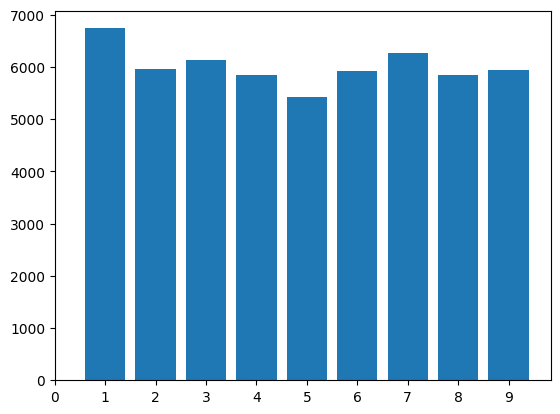

(None, (60000,))

In [28]:
plt.hist(train_data_y, bins=np.arange(0.5, 10.5, 1), rwidth=0.8)
plt.xticks(range(10))
plt.show(), train_data_y.shape

(<matplotlib.image.AxesImage at 0x1efb8cd7ed0>, np.int64(6))

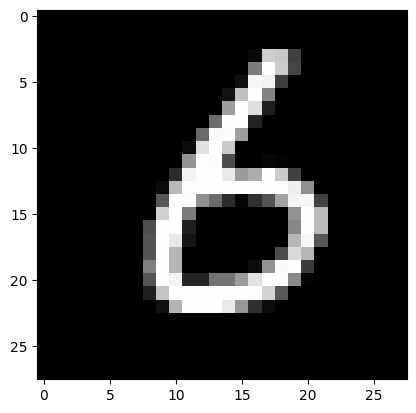

In [29]:
random_idx = np.random.randint(0, len(train_data_X))
plt.imshow(train_data_X[random_idx].reshape(28, 28), cmap='gray'), train_data_y[random_idx]

In [30]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torch.nn.functional import one_hot
from torch.optim import SGD
from torch import nn

In [31]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.1307,), std=(0.3081,))
])

class CustomDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.data = self.df.to_numpy()
        self.transform = transform

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        image, label = sample[1:], sample[0]
        image = image.reshape(28, 28, 1).astype(np.uint8)
        label = one_hot(torch.tensor(label, dtype=torch.long), num_classes=10)
        if self.transform:
            image = self.transform(image)
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        return image, label

In [32]:
train_dataset = CustomDataset(csv_path_train, transform=transform)
test_dataset = CustomDataset(csv_path_test, transform=transform)
len(train_data), train_dataset[0]

(60000,
 (Image([[[-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242, -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
           -0.4242

In [33]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32,shuffle=False)

In [42]:
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.layer_2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.layer_1(x)))
        x = self.pool(torch.relu(self.layer_2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [44]:
epoch_no = 20
model = MNISTModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for epoch in range(epoch_no):
    model.train()
    losses = []
    for i, (image_batch, label) in enumerate(train_dataloader):
        optimizer.zero_grad()
        outputs = model(image_batch)
        loss = loss_fn(outputs)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    avg_loss = sum(losses) / len(losses)
    print(f"Epoch [{epoch+1}/{epoch_no}], Loss: {avg_loss:.4f}")

Epoch [1/20], Loss: 0.2099
Epoch [2/20], Loss: 0.1349
Epoch [3/20], Loss: 0.1202
Epoch [4/20], Loss: 0.1161
Epoch [5/20], Loss: 0.1139
Epoch [6/20], Loss: 0.1076
Epoch [7/20], Loss: 0.1053
Epoch [8/20], Loss: 0.1005
Epoch [9/20], Loss: 0.1044
Epoch [10/20], Loss: 0.1007
Epoch [11/20], Loss: 0.1053
Epoch [12/20], Loss: 0.1058
Epoch [13/20], Loss: 0.1042
Epoch [14/20], Loss: 0.0996
Epoch [15/20], Loss: 0.1017
Epoch [16/20], Loss: 0.1004
Epoch [17/20], Loss: 0.0974
Epoch [18/20], Loss: 0.1011
Epoch [19/20], Loss: 0.0993
Epoch [20/20], Loss: 0.0985


In [45]:
torch.save(model.state_dict(), "mnist_model.pth")